# Modelos Word2Vec

En este libro, conoceremos los fundamentos de los modelos Word2Vec como representaciones de tokens por medio de embeddings estáticos

Intuiremos el concepto de la similitud entre vectores, que representan la similitud semántica y miraremos el concepto de la aritmética de embeddings.

La librería GenSim permite descargar y trabajar con los modelos de embeddings disponibles. Esta librería provee un modelo de consulta que transforma palabras o tokens en vectores.

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Word2Vec: Google News 300

El modelo `word2vec-google-news-300` es una representación vectorial de palabras (*word embeddings*) entrenada sobre una gran colección de textos de noticias de Google.

En Python puede cargarse utilizando la biblioteca **Gensim**

## Historia

Word2Vec fue presentado en 2013 por un equipo de investigadores de Google liderado por Tomas Mikolov. Su aparición representó un avance importante en el procesamiento de lenguaje natural, porque permitió aprender automáticamente representaciones numéricas de las palabras a partir de grandes cantidades de texto.

La idea fundamental es sencilla: las palabras que aparecen en contextos similares tienden a tener significados relacionados.

En lugar de representar cada palabra mediante un identificador o mediante un vector one-hot, Word2Vec aprende para cada palabra un vector denso de números reales.

Por ejemplo:

$$ \text{king} \rightarrow [0.12,-0.43,0.71,\ldots] $$

La característica más interesante es que la geometría de estos vectores captura parcialmente las relaciones semánticas y sintácticas entre las palabras.

## El modelo Google News

Es un modelo Word2Vec previamente entrenado por Google sobre aproximadamente 100 mil millones de palabras provenientes del corpus Google News.

Sus principales características son:
- Corpus: Google News.
- Tamaño del corpus: aproximadamente 100 mil millones de palabras.
- Vocabulario: aproximadamente 3 millones de palabras y expresiones.
- Dimensión del embedding: 300.
- Idioma predominante: inglés.
- Arquitectura: Word2Vec.
- Tipo de representación: vectores densos de números reales.
- Incluye palabras y algunas expresiones compuestas, como New_York.

Por tanto, cada palabra conocida por el modelo está representada mediante un punto en un espacio de dimensión 300:

$$ \mathbf{w}\in\mathbb{R}^{300} $$



In [31]:
from pathlib import Path
from gensim.models import KeyedVectors
import gensim.downloader as api

modelo_path = Path("word2vec-google-news-300.kv")

# Si el modelo ya existe, cargarlo localmente.
# Si no existe, descargarlo y guardarlo para usos posteriores.

if modelo_path.exists():
    print("Cargando Word2Vec desde disco...")
    wv = KeyedVectors.load(str(modelo_path))
else:
    print("Modelo no encontrado. Descargando Word2Vec...")
    wv = api.load("word2vec-google-news-300")

    print("Guardando modelo localmente...")
    wv.save(str(modelo_path))

print("Word2Vec listo.")

Cargando Word2Vec desde disco...
Word2Vec listo.


In [37]:
wv['manuel']

array([ 2.62451172e-03,  3.56445312e-02,  1.08398438e-01, -3.24707031e-02,
       -5.95703125e-02,  1.00097656e-01, -2.13623047e-02, -2.09960938e-02,
        2.00195312e-01, -2.19726562e-02, -2.47802734e-02, -1.45507812e-01,
       -2.01171875e-01, -1.15966797e-02, -8.69140625e-02,  4.71191406e-02,
        9.03320312e-02,  1.61132812e-01, -1.31835938e-02, -5.37109375e-02,
        9.27734375e-02, -1.56250000e-01,  7.71484375e-02,  6.88476562e-02,
       -1.59912109e-02, -6.07910156e-02, -1.43554688e-01,  1.33789062e-01,
       -9.37500000e-02, -1.67236328e-02,  1.55273438e-01, -9.77516174e-05,
       -4.00390625e-02, -9.17968750e-02, -1.51367188e-01,  7.75146484e-03,
        6.49414062e-02,  1.82617188e-01,  1.78710938e-01, -7.66601562e-02,
       -2.69775391e-02,  6.12792969e-02,  1.86523438e-01,  8.78906250e-02,
        2.06054688e-01, -1.04003906e-01, -1.05468750e-01, -1.04980469e-01,
       -4.54101562e-02,  1.68945312e-01, -2.22656250e-01,  1.49414062e-01,
        1.76757812e-01, -

In [42]:
len(wv)

3000000

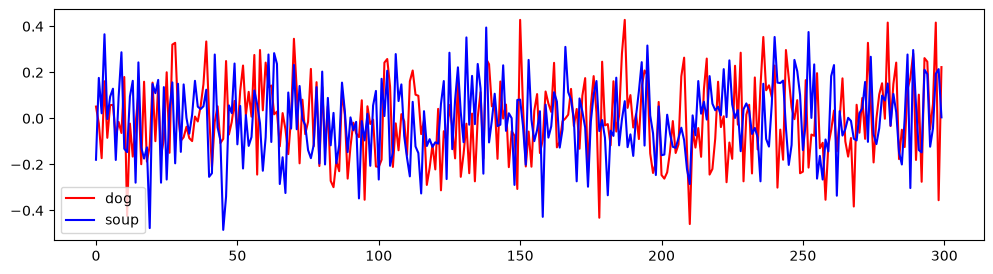

In [41]:
# Hagamos el diagrama de dos vectores aparentemente relacionados. La única diferencia entre ellos es el número
plt.figure(figsize=(12,3))
plt.plot(wv['dog'], '-r', label='dog')
plt.plot(wv['soup'], '-b', label='soup')
plt.legend()


In [43]:
# Definamos las funciones de similitud del coseno y la función de distancia del coseno
def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
def cosine_distance(u, v):
    return 1 - cosine_similarity(u, v)

#Ahora podemos evaluar que tan cercanas son dos palabras. Esto no es un concepto biológico o temático, sino simplemente por la frecuencia con que aparecen juntas las palabras.
#Lo invito a ensayar otras palabras para mirar su similitud.
w1='dog'
w2='dogs'
print(f"La similitud del coseno entre las palarbras {w1} y {w2} es {cosine_similarity(wv[w1],wv[w2])}")

La similitud del coseno entre las palarbras dog y dogs es 0.8680490255355835


In [49]:
#Vamos a mirar las palabras mas cercanas a cierta palabra. Esto es, las palabras que tienen la más alta similitud con una palabra cualquiera

w='lindsay_lohan'
print('\n5 palabras más cercanas a: ',w)
for a,b in wv.most_similar(w, topn=5):
  print(f'Palabra: {a}, Similitud del coseno: {cosine_similarity(wv[w], wv[a])}')



5 palabras más cercanas a:  lindsay_lohan


Palabra: britney, Similitud del coseno: 0.7551742196083069
Palabra: lindsay, Similitud del coseno: 0.7357141971588135
Palabra: megan_fox, Similitud del coseno: 0.7271660566329956
Palabra: heidi, Similitud del coseno: 0.7254078984260559
Palabra: charlie_sheen, Similitud del coseno: 0.7245847582817078


In [48]:
#Ensayemos algo de álgebra de los wordEmbeddings
queen=wv['king']-wv['man']+wv['woman']

print('\n5 palabras más cercanas al vector obtenido: de acuerdo con King-Man+woman ' )
for a,b in wv.similar_by_vector(queen, topn=5):
  print(f'Palabra: {a}, Similitud del coseno: {b}')

# ENsayemnos otra relación
berlin=wv['paris']-wv['france']+wv['germany']

print('\n5 palabras más cercanas al vector obtenido: de acuerdo con paris-france-germany')
for a,b in wv.similar_by_vector(berlin, topn=5):
  print(f'Palabra: {a}, Similitud del coseno: {b}')




5 palabras más cercanas al vector obtenido: de acuerdo con King-Man+woman 
Palabra: king, Similitud del coseno: 0.8449392318725586
Palabra: queen, Similitud del coseno: 0.7300517559051514
Palabra: monarch, Similitud del coseno: 0.645466148853302
Palabra: princess, Similitud del coseno: 0.6156251430511475
Palabra: crown_prince, Similitud del coseno: 0.5818676352500916

5 palabras más cercanas al vector obtenido: de acuerdo con paris-france-germany
Palabra: paris, Similitud del coseno: 0.7316325902938843
Palabra: germany, Similitud del coseno: 0.6952009797096252
Palabra: berlin, Similitud del coseno: 0.48383620381355286
Palabra: german, Similitud del coseno: 0.4694601595401764
Palabra: lindsay_lohan, Similitud del coseno: 0.4535733461380005


La pregunta acá es: Cómo hacemos para construir un sistema que nos permita entrenar un sistema de detección de sentimientos?

Haremos algo similar a la unidad anterior, pero en lugar de utilizar una representación de BoW que inclusive requiere disminuir el vocabulario, haremos una representación de embeddings.

In [50]:
#Ejemplo de clasificación de sentimientos basado en Word2Vec
with open('sentimientos.csv', encoding='utf-8') as file:
  lineas=file.readlines()

In [26]:
#Procesaremos los datos cargados, buscando que haya datos de polaridad y que se eliminen algunas comas dentro del texto
textos=[]
polaridades=[]
acuerdos=[]
for cad in lineas[1:]:
  data=cad.split(',') #Se recomienda no hacer lower, debido a que el WV es sensible a las minúsculas y mayúsuculas. Se buscarán ambas luego
  if(len(data)==3):
    texto, polaridad, acuerdo=data
    polaridad=polaridad.lower()
  else:
    #print(cad, data)
    if(len(data)>3):
      texto=' '.join(data[:-2])
      polaridad=data[-2].lower()
      acuerdo=data[-1]
      #print(cad,texto, polaridad, acuerdo)
    else:
      texto=''
      polaridad=''
      acuerdo=''
  if(len(texto)>0):
    textos.append(texto)
    polaridades.append(polaridad)
    acuerdos.append(acuerdo.replace('\n',''))


In [27]:
#Ahora si, hagamos la unión de los word2Vec de cada frase
import torch
data2=[]
replace={'n':0, 'n+':0, 'neu':1, 'p':2, 'p+':2}
for doc, pol in zip(textos, polaridades):
  val=np.zeros(300)
  n=0
  for di in doc.split():
    if(di in wv.key_to_index or di.lower() in wv.key_to_index):
      if(di.lower() in wv.key_to_index):
        di=di.lower()
      val+=wv[di]
      n+=1
  if(n>0 and pol!='none'):
    data2.append((val/n, replace[pol]))
  #En la línea anterior guardamos los vectores promedio de las palabras que aparecieron en Word2Vec de cada tweet
  #Algo importante para reconocer, es que como es un modelo no entrenado por nosotros, algunas palabras no estarán allí representadas.
  #Utilizaremos la representación disponible unicamente

from sklearn.model_selection import train_test_split
data_train, data_test=train_test_split(data2, train_size=0.7, shuffle=True)

print(f'Datos que quedaron disponibles en total: {len(data2)}, \nDatos para entrenaiento: {len(data_train)}, Datos para validación {len(data_test)}')
train_loader = torch.utils.data.DataLoader(data_train, batch_size=128, shuffle=True)

Datos que quedaron disponibles en total: 5703, 
Datos para entrenaiento: 3992, Datos para validación 1711


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

L=300
model=torch.nn.Sequential(
    torch.nn.Linear(L,100),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.2),
    torch.nn.Linear(100,50),
    torch.nn.ReLU(),
    torch.nn.Linear(50,3),
    torch.nn.ReLU()
).to(device)


Epoch:  1995  Average error:  0.0040786615820252335

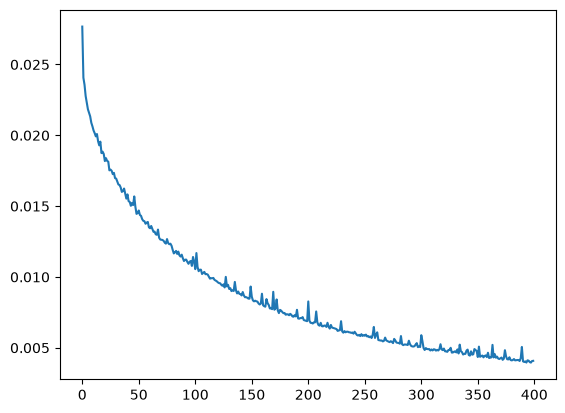

In [55]:

cross_el = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
epoch = 2000

err=[]
vErr=[]
for e in range(epoch):
    for data in train_loader:      #for data in enumerate(train_loader):
        x, y = data                #    batch, (x,y)= data
        optimizer.zero_grad()
        output = model(x.float().to(device))
        loss = cross_el(output, y.to(device))
        loss.backward()
        optimizer.step()
        err.append(loss.cpu().item())
    if(e %5==0):
      vErr.append(np.mean(err))
      print('\rEpoch: ',e,' Average error: ', vErr[-1], end='')
      err=[]
plt.plot(vErr)

<Axes: >

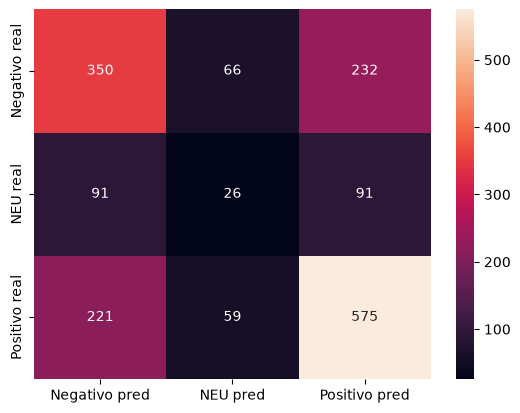

In [56]:
#Verifiquemos el comportamiento del modelo:
test_loader=torch.utils.data.DataLoader(data_test, batch_size=len(data_test), shuffle=True)
xi, yi=next(iter(test_loader))
model.eval()
output = model(xi.to(device).float()).detach().cpu().numpy()
M=np.zeros((3,3), dtype=int)
for out, y in zip(output, yi):
  M[y.numpy(), np.argmax(out)]+=1
import pandas as pd
df=pd.DataFrame(M, index=['Negativo real','NEU real','Positivo real'], columns=['Negativo pred','NEU pred','Positivo pred'])
import seaborn as sns
sns.heatmap(df, annot=True, fmt='d')

In [58]:
w='right'
print('\n5 palabras más cercanas a: ',w)
for a,b in wv.most_similar(w, topn=5):
  print(f'Palabra: {a}, Similitud del coseno: {cosine_similarity(wv[w], wv[a])}')


5 palabras más cercanas a:  right
Palabra: Right, Similitud del coseno: 0.5703941583633423
Palabra: wrong, Similitud del coseno: 0.5534271597862244
Palabra: ##.Help_us, Similitud del coseno: 0.5502840280532837
Palabra: Goodwill_Catanese, Similitud del coseno: 0.5159174203872681
Palabra: left, Similitud del coseno: 0.49213993549346924
